<a href="https://colab.research.google.com/github/yordanET/reglasAsociacion/blob/main/Reglas_De_Asociacion_CRISP_DM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reglas de asociación con CRISP-DM
  
**Dataset:** `basket_analysis.csv`, almacenado en Google Drive.

Este notebook desarrolla las seis fases de **CRISP-DM**:

1. Comprensión del negocio  
2. Comprensión de los datos  
3. Preparación de los datos  
4. Modelado  
5. Evaluación   

El objetivo es descubrir productos que suelen comprarse juntos mediante el algoritmo **Apriori** y generar reglas evaluadas con soporte, confianza, lift, leverage y conviction.

> **Uso:** abra el notebook en Google Colab, ejecute las celdas en orden y autorice el acceso a Google Drive cuando se solicite.


## 1. Comprensión del negocio

### Objetivo del negocio
Una tienda desea conocer los patrones de compra de sus clientes para identificar productos que suelen adquirirse en una misma transacción.

### Problema
La empresa registra qué productos aparecen en cada compra, pero no conoce las relaciones existentes entre ellos.

### Objetivo de minería de datos
Encontrar conjuntos frecuentes de productos y generar reglas del tipo:

> Si un cliente compra **A**, entonces también podría comprar **B**.

### Posibles decisiones
- Crear promociones combinadas.
- Organizar mejor los productos.
- Recomendar artículos relacionados.
- Diseñar paquetes de productos.
- Apoyar campañas de venta cruzada.

Las reglas muestran asociaciones estadísticas y no implican causalidad.


In [22]:
# Importación de librerías
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda valor: f"{valor:.4f}")


### Conexión con Google Drive

El notebook monta Google Drive y busca automáticamente el archivo `basket_analysis.csv` dentro de **Mi unidad**.  
Cuando existan varios archivos con ese nombre, puede indicarse la ruta exacta en `RUTA_DATASET_MANUAL`.


In [23]:
# Montar Google Drive
try:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_DRIVE = Path("/content/drive/MyDrive")
except ImportError:
    # Permite probar el notebook fuera de Google Colab.
    print("No se detectó Google Colab. Se utilizará la carpeta actual.")
    BASE_DRIVE = Path.cwd()

# Configuración
NOMBRE_DATASET = "basket_analysis.csv"


RUTA_DATASET_MANUAL = "/content/drive/MyDrive/clases-2026-1/mineria/segunda_unidad/basket_analysis.csv"

CARPETA_SALIDA = BASE_DRIVE / "Reglas_Asociacion_Resultados"
CARPETA_SALIDA.mkdir(parents=True, exist_ok=True)

print("Carpeta base:", BASE_DRIVE)
print("Carpeta de resultados:", CARPETA_SALIDA)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Carpeta base: /content/drive/MyDrive
Carpeta de resultados: /content/drive/MyDrive/Reglas_Asociacion_Resultados


In [24]:
# Localización y carga del conjunto de datos
if RUTA_DATASET_MANUAL.strip():
    ruta_dataset = Path(RUTA_DATASET_MANUAL.strip())
    if not ruta_dataset.exists():
        raise FileNotFoundError(
            f"No se encontró el archivo en la ruta indicada: {ruta_dataset}"
        )
else:
    coincidencias = sorted(BASE_DRIVE.rglob(NOMBRE_DATASET))

    if not coincidencias:
        raise FileNotFoundError(
            f"No se encontró '{NOMBRE_DATASET}' dentro de {BASE_DRIVE}. "
            "Verifique el nombre del archivo o complete RUTA_DATASET_MANUAL."
        )

    ruta_dataset = coincidencias[0]

    if len(coincidencias) > 1:
        print("Se encontraron varios archivos con el mismo nombre:")
        for numero, archivo in enumerate(coincidencias, start=1):
            print(f"  {numero}. {archivo}")
        print("\nSe utilizará el primero. Para elegir otro, complete RUTA_DATASET_MANUAL.")

df = pd.read_csv(ruta_dataset)

print("\nDataset cargado correctamente")
print("Ruta:", ruta_dataset)
print("Dimensiones:", df.shape)
display(df.head())



Dataset cargado correctamente
Ruta: /content/drive/MyDrive/clases-2026-1/mineria/segunda_unidad/basket_analysis.csv
Dimensiones: (999, 17)


,Unnamed: 0,Apple,Bread,Butter,Cheese,Corn,Dill,Eggs,Ice cream,Kidney Beans,Milk,Nutmeg,Onion,Sugar,Unicorn,Yogurt,chocolate
0,0,False,True,False,False,True,True,False,True,False,False,False,False,True,False,True,True
1,1,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
2,2,True,False,True,False,False,True,False,True,False,True,False,False,False,False,True,True
3,3,False,False,True,True,False,True,False,False,False,True,True,True,False,False,False,False
4,4,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False


## 2. Comprensión de los datos

En esta fase se revisan las dimensiones, los tipos de datos, los valores faltantes, las columnas de índice, las transacciones duplicadas y la frecuencia de aparición de cada producto.


In [25]:
# Información general
print("Número de transacciones:", df.shape[0])
print("Número inicial de columnas:", df.shape[1])

print("\nTipos de datos:")
display(df.dtypes.to_frame("Tipo"))

print("\nValores faltantes por columna:")
faltantes = df.isnull().sum().to_frame("Faltantes")
display(faltantes)

print("\nFilas duplicadas:", df.duplicated().sum())
print(
    "Nota: las transacciones idénticas no se eliminan automáticamente, "
    "porque pueden representar compras diferentes."
)


Número de transacciones: 999
Número inicial de columnas: 17

Tipos de datos:


,Tipo
Unnamed: 0,int64
Apple,bool
Bread,bool
Butter,bool
Cheese,bool
Corn,bool
Dill,bool
Eggs,bool
Ice cream,bool
Kidney Beans,bool



Valores faltantes por columna:


,Faltantes
Unnamed: 0,0
Apple,0
Bread,0
Butter,0
Cheese,0
Corn,0
Dill,0
Eggs,0
Ice cream,0
Kidney Beans,0



Filas duplicadas: 0
Nota: las transacciones idénticas no se eliminan automáticamente, porque pueden representar compras diferentes.


In [26]:
# Estandarización inicial de nombres e identificación de columnas de índice
df.columns = [str(columna).strip() for columna in df.columns]

if df.columns.duplicated().any():
    repetidas = df.columns[df.columns.duplicated()].tolist()
    raise ValueError(f"Existen nombres de columnas duplicados: {repetidas}")

columnas_indice = [
    columna for columna in df.columns
    if columna.lower().startswith("unnamed")
]

print("Columnas de índice detectadas:", columnas_indice)


Columnas de índice detectadas: ['Unnamed: 0']


### Interpretación inicial

Cada fila representa una transacción y cada columna de producto indica su presencia o ausencia.  
El valor `True` o `1` representa que el producto fue comprado, mientras que `False` o `0` representa que no fue incluido.


## 3. Preparación de los datos

Se eliminan las columnas de índice, se convierten las variables a formato booleano y se valida que no existan valores desconocidos. A diferencia de una eliminación automática, esta validación evita perder transacciones sin advertencia.


In [27]:
# Eliminación de columnas innecesarias
datos_originales = df.drop(columns=columnas_indice, errors="ignore").copy()

MAPA_BOOLEANO = {
    "true": True,
    "false": False,
    "1": True,
    "0": False,
    "si": True,
    "sí": True,
    "no": False,
    "yes": True,
    "y": True,
    "n": False,
    "t": True,
    "f": False
}

def convertir_serie_booleana(serie):
    """Convierte una serie a booleano y conserva NaN para valores inválidos."""
    if pd.api.types.is_bool_dtype(serie):
        return serie.astype("boolean")

    if pd.api.types.is_numeric_dtype(serie):
        return serie.map({1: True, 0: False}).astype("boolean")

    normalizada = serie.astype("string").str.strip().str.lower()
    return normalizada.map(MAPA_BOOLEANO).astype("boolean")


datos = datos_originales.apply(convertir_serie_booleana)

invalidos_por_columna = datos.isna().sum()
invalidos_por_columna = invalidos_por_columna[invalidos_por_columna > 0]

if not invalidos_por_columna.empty:
    display(invalidos_por_columna.to_frame("Valores no reconocidos"))
    raise ValueError(
        "Se encontraron valores que no pueden interpretarse como presencia/ausencia. "
        "Revise las columnas mostradas antes de continuar."
    )

datos = datos.astype(bool)

# Eliminar únicamente transacciones completamente vacías
transacciones_vacias = datos.sum(axis=1).eq(0)
cantidad_vacias = int(transacciones_vacias.sum())

if cantidad_vacias:
    datos = datos.loc[~transacciones_vacias].copy()
    print(f"Se eliminaron {cantidad_vacias} transacciones sin productos.")

if datos.empty:
    raise ValueError("No quedaron transacciones válidas después de la preparación.")

print("Dimensiones después de la preparación:", datos.shape)
print("Todos los datos son booleanos:", all(tipo == bool for tipo in datos.dtypes))
display(datos.head())


Dimensiones después de la preparación: (999, 16)
Todos los datos son booleanos: True


,Apple,Bread,Butter,Cheese,Corn,Dill,Eggs,Ice cream,Kidney Beans,Milk,Nutmeg,Onion,Sugar,Unicorn,Yogurt,chocolate
0,False,True,False,False,True,True,False,True,False,False,False,False,True,False,True,True
1,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
2,True,False,True,False,False,True,False,True,False,True,False,False,False,False,True,True
3,False,False,True,True,False,True,False,False,False,True,True,True,False,False,False,False
4,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [28]:
# Resumen de frecuencia y soporte individual
frecuencia = datos.sum().sort_values(ascending=False)
soporte_individual = frecuencia / len(datos)

resumen_productos = pd.DataFrame({
    "Frecuencia": frecuencia.astype(int),
    "Soporte": soporte_individual
})

display(resumen_productos)


,Frecuencia,Soporte
chocolate,421,0.4214
Butter,420,0.4204
Yogurt,420,0.4204
Ice cream,410,0.4104
Sugar,409,0.4094
Kidney Beans,408,0.4084
Corn,407,0.4074
Milk,405,0.4054
Cheese,404,0.4044
Onion,403,0.4034


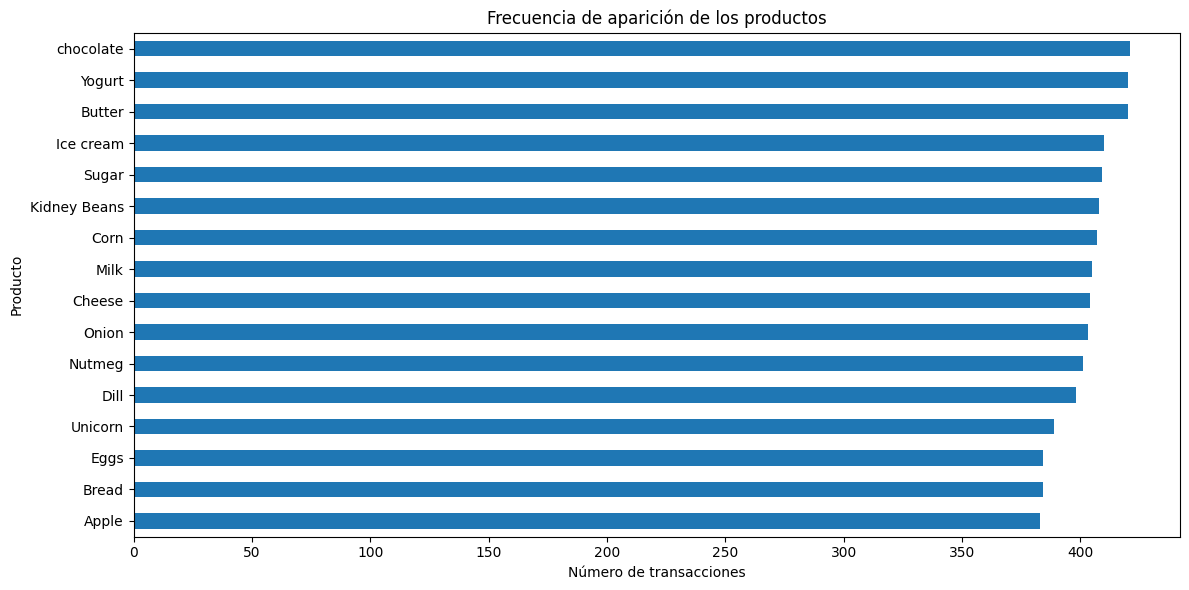

In [29]:
# Gráfico de frecuencia de productos
plt.figure(figsize=(12, 6))
frecuencia.sort_values().plot(kind="barh")
plt.title("Frecuencia de aparición de los productos")
plt.xlabel("Número de transacciones")
plt.ylabel("Producto")
plt.tight_layout()
plt.show()


### Interpretación del gráfico

Las barras más largas corresponden a los productos que aparecen en una mayor cantidad de transacciones. Esta visualización permite identificar los artículos más populares antes de estudiar las combinaciones frecuentes.


,Productos por transacción
count,999.0000
mean,6.4525
std,2.9504
min,1.0000
25%,4.0000
50%,7.0000
75%,9.0000
max,13.0000


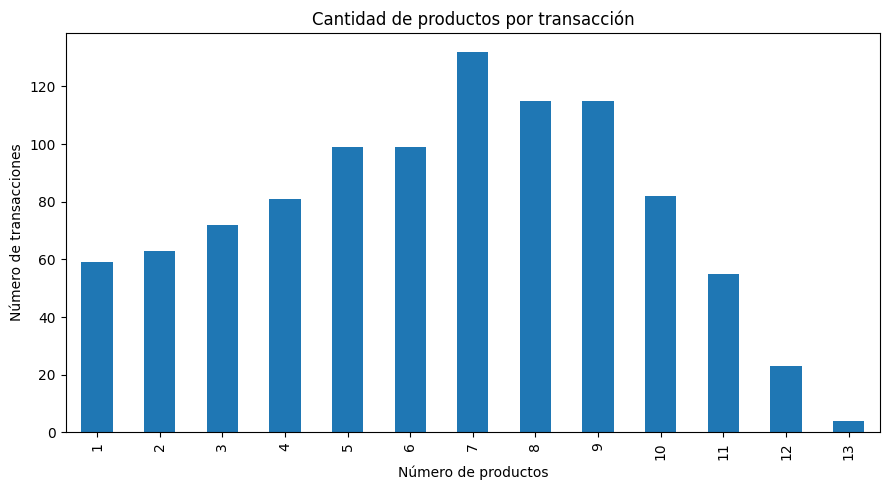

In [30]:
# Cantidad de productos por transacción
productos_por_compra = datos.sum(axis=1)

display(productos_por_compra.describe().to_frame("Productos por transacción"))

plt.figure(figsize=(9, 5))
productos_por_compra.value_counts().sort_index().plot(kind="bar")
plt.title("Cantidad de productos por transacción")
plt.xlabel("Número de productos")
plt.ylabel("Número de transacciones")
plt.tight_layout()
plt.show()


## 4. Modelado

Se implementa Apriori con generación progresiva y poda de candidatos. Solo se evalúan combinaciones cuyos subconjuntos también son frecuentes, lo que reduce cálculos innecesarios.

### Parámetros iniciales
- **Soporte mínimo:** 0.08  
- **Confianza mínima:** 0.50  
- **Lift mínimo:** 1.00  
- **Tamaño máximo:** 3 productos  

Los valores pueden ajustarse según la cantidad de transacciones y el nivel de exigencia del análisis.


In [31]:
def apriori_booleano(matriz, soporte_minimo=0.08, max_tamano=3):
    """Obtiene conjuntos frecuentes mediante el principio Apriori."""
    if matriz.empty:
        raise ValueError("La matriz transaccional está vacía.")
    if not 0 < soporte_minimo <= 1:
        raise ValueError("soporte_minimo debe estar entre 0 y 1.")
    if max_tamano < 1:
        raise ValueError("max_tamano debe ser al menos 1.")

    soportes = {}

    # Nivel 1: productos individuales
    nivel_actual = set()
    for producto in matriz.columns:
        conjunto = frozenset([producto])
        soporte = matriz[producto].mean()

        if soporte >= soporte_minimo:
            soportes[conjunto] = float(soporte)
            nivel_actual.add(conjunto)

    # Niveles 2, 3, ..., max_tamano
    for tamano in range(2, max_tamano + 1):
        candidatos = set()
        nivel_ordenado = sorted(
            nivel_actual,
            key=lambda conjunto: tuple(sorted(conjunto))
        )

        for i in range(len(nivel_ordenado)):
            for j in range(i + 1, len(nivel_ordenado)):
                candidato = nivel_ordenado[i] | nivel_ordenado[j]

                if len(candidato) != tamano:
                    continue

                # Poda: todos los subconjuntos de tamaño k-1 deben ser frecuentes
                subconjuntos_frecuentes = all(
                    frozenset(subconjunto) in nivel_actual
                    for subconjunto in combinations(candidato, tamano - 1)
                )

                if subconjuntos_frecuentes:
                    candidatos.add(candidato)

        siguiente_nivel = set()

        for candidato in candidatos:
            soporte = matriz[list(candidato)].all(axis=1).mean()

            if soporte >= soporte_minimo:
                soportes[candidato] = float(soporte)
                siguiente_nivel.add(candidato)

        if not siguiente_nivel:
            break

        nivel_actual = siguiente_nivel

    frecuentes = pd.DataFrame([
        {
            "itemset": tuple(sorted(conjunto)),
            "tamaño": len(conjunto),
            "frecuencia_absoluta": int(round(soporte * len(matriz))),
            "soporte": soporte
        }
        for conjunto, soporte in soportes.items()
    ])

    if not frecuentes.empty:
        frecuentes = frecuentes.sort_values(
            ["soporte", "tamaño"],
            ascending=[False, True]
        ).reset_index(drop=True)

    return soportes, frecuentes


In [32]:
# Parámetros del modelo
soporte_minimo = 0.08
confianza_minima = 0.50
lift_minimo = 1.00
max_tamano = 3

soportes, itemsets_frecuentes = apriori_booleano(
    datos,
    soporte_minimo=soporte_minimo,
    max_tamano=max_tamano
)

print("Parámetros utilizados:")
print(f"- Soporte mínimo: {soporte_minimo:.2f}")
print(f"- Confianza mínima: {confianza_minima:.2f}")
print(f"- Lift mínimo: {lift_minimo:.2f}")
print(f"- Tamaño máximo: {max_tamano}")
print("\nNúmero de conjuntos frecuentes:", len(itemsets_frecuentes))

display(itemsets_frecuentes.head(20))


Parámetros utilizados:
- Soporte mínimo: 0.08
- Confianza mínima: 0.50
- Lift mínimo: 1.00
- Tamaño máximo: 3

Número de conjuntos frecuentes: 615


,itemset,tamaño,frecuencia_absoluta,soporte
0,"(chocolate,)",1,421,0.4214
1,"(Butter,)",1,420,0.4204
2,"(Yogurt,)",1,420,0.4204
3,"(Ice cream,)",1,410,0.4104
4,"(Sugar,)",1,409,0.4094
5,"(Kidney Beans,)",1,408,0.4084
6,"(Corn,)",1,407,0.4074
7,"(Milk,)",1,405,0.4054
8,"(Cheese,)",1,404,0.4044
9,"(Onion,)",1,403,0.4034


In [33]:
def generar_reglas(soportes, confianza_minima=0.50, lift_minimo=1.00):
    """Genera reglas de asociación desde los conjuntos frecuentes."""
    if not 0 < confianza_minima <= 1:
        raise ValueError("confianza_minima debe estar entre 0 y 1.")
    if lift_minimo < 0:
        raise ValueError("lift_minimo no puede ser negativo.")

    reglas = []

    for conjunto, soporte_conjunto in soportes.items():
        if len(conjunto) < 2:
            continue

        for tamano in range(1, len(conjunto)):
            for antecedente_tuple in combinations(conjunto, tamano):
                antecedente = frozenset(antecedente_tuple)
                consecuente = conjunto - antecedente

                soporte_antecedente = soportes.get(antecedente)
                soporte_consecuente = soportes.get(consecuente)

                if soporte_antecedente is None or soporte_consecuente is None:
                    continue

                confianza = soporte_conjunto / soporte_antecedente
                lift = confianza / soporte_consecuente
                leverage = soporte_conjunto - (
                    soporte_antecedente * soporte_consecuente
                )
                conviction = (
                    (1 - soporte_consecuente) / (1 - confianza)
                    if confianza < 1
                    else np.inf
                )

                if confianza >= confianza_minima and lift >= lift_minimo:
                    reglas.append({
                        "antecedente": ", ".join(sorted(antecedente)),
                        "consecuente": ", ".join(sorted(consecuente)),
                        "soporte": soporte_conjunto,
                        "confianza": confianza,
                        "lift": lift,
                        "leverage": leverage,
                        "conviction": conviction
                    })

    columnas = [
        "antecedente", "consecuente", "soporte", "confianza",
        "lift", "leverage", "conviction"
    ]
    reglas_df = pd.DataFrame(reglas, columns=columnas)

    if not reglas_df.empty:
        reglas_df = (
            reglas_df
            .sort_values(
                ["lift", "confianza", "soporte"],
                ascending=False
            )
            .drop_duplicates()
            .reset_index(drop=True)
        )

    return reglas_df


In [34]:
reglas = generar_reglas(
    soportes,
    confianza_minima=confianza_minima,
    lift_minimo=lift_minimo
)

print("Número de reglas obtenidas:", len(reglas))

if reglas.empty:
    print(
        "No se generaron reglas con los umbrales actuales. "
        "Pruebe reduciendo el soporte o la confianza mínima."
    )
else:
    display(reglas.head(20))


Número de reglas obtenidas: 548


,antecedente,consecuente,soporte,confianza,lift,leverage,conviction
0,"Cheese, Dill",Onion,0.1021,0.5763,1.4285,0.0306,1.4080
1,"Dill, Unicorn",chocolate,0.1011,0.6012,1.4266,0.0302,1.4508
2,"Dill, Milk",chocolate,0.1141,0.6000,1.4238,0.0340,1.4464
3,"Dill, chocolate",Milk,0.1141,0.5729,1.4131,0.0334,1.3921
4,"Bread, Dill",Yogurt,0.0951,0.5938,1.4123,0.0278,1.4267
5,"Cheese, Unicorn",Kidney Beans,0.0981,0.5765,1.4115,0.0286,1.3968
6,"Cheese, Onion",Dill,0.1021,0.5514,1.3839,0.0283,1.3409
7,"Corn, Sugar",Apple,0.0991,0.5294,1.3809,0.0273,1.3103
8,"Cheese, Milk",Kidney Beans,0.0971,0.5640,1.3809,0.0268,1.3567
9,"Bread, Nutmeg",Yogurt,0.0991,0.5789,1.3771,0.0271,1.3765


## 5. Evaluación

### Métricas utilizadas

- **Soporte:** proporción de transacciones que contienen simultáneamente el antecedente y el consecuente.
- **Confianza:** probabilidad de encontrar el consecuente cuando aparece el antecedente.
- **Lift:** compara la relación observada con la esperada si ambos conjuntos fueran independientes.
  - Lift > 1: asociación positiva.
  - Lift = 1: independencia.
  - Lift < 1: asociación negativa.
- **Leverage:** diferencia entre la frecuencia conjunta observada y la esperada.
- **Conviction:** mide el grado de implicación de la regla considerando sus incumplimientos.


In [35]:
# Reglas más interesantes
if not reglas.empty:
    top_reglas = reglas.head(15).copy()

    for columna in ["soporte", "confianza", "lift", "leverage", "conviction"]:
        top_reglas[columna] = top_reglas[columna].round(4)

    display(top_reglas)


,antecedente,consecuente,soporte,confianza,lift,leverage,conviction
0,"Cheese, Dill",Onion,0.1021,0.5763,1.4285,0.0306,1.4080
1,"Dill, Unicorn",chocolate,0.1011,0.6012,1.4266,0.0302,1.4508
2,"Dill, Milk",chocolate,0.1141,0.6000,1.4238,0.0340,1.4464
3,"Dill, chocolate",Milk,0.1141,0.5729,1.4131,0.0334,1.3921
4,"Bread, Dill",Yogurt,0.0951,0.5938,1.4123,0.0278,1.4267
5,"Cheese, Unicorn",Kidney Beans,0.0981,0.5765,1.4115,0.0286,1.3968
6,"Cheese, Onion",Dill,0.1021,0.5514,1.3839,0.0283,1.3409
7,"Corn, Sugar",Apple,0.0991,0.5294,1.3809,0.0273,1.3103
8,"Cheese, Milk",Kidney Beans,0.0971,0.5640,1.3809,0.0268,1.3567
9,"Bread, Nutmeg",Yogurt,0.0991,0.5789,1.3771,0.0271,1.3765


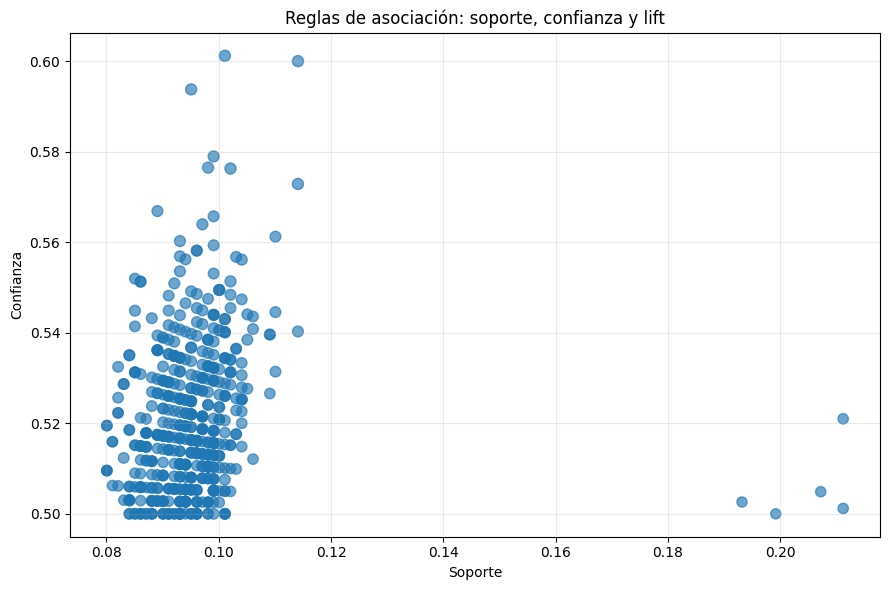

In [36]:
# Visualización: soporte, confianza y lift
if not reglas.empty:
    plt.figure(figsize=(9, 6))
    plt.scatter(
        reglas["soporte"],
        reglas["confianza"],
        s=np.clip(reglas["lift"] * 45, 20, 300),
        alpha=0.65
    )
    plt.title("Reglas de asociación: soporte, confianza y lift")
    plt.xlabel("Soporte")
    plt.ylabel("Confianza")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


### Interpretación

Cada punto representa una regla. La posición horizontal muestra el soporte, la posición vertical indica la confianza y el tamaño representa el lift. Las reglas cercanas a la parte superior y con puntos de mayor tamaño presentan una combinación destacada de confianza y asociación positiva.


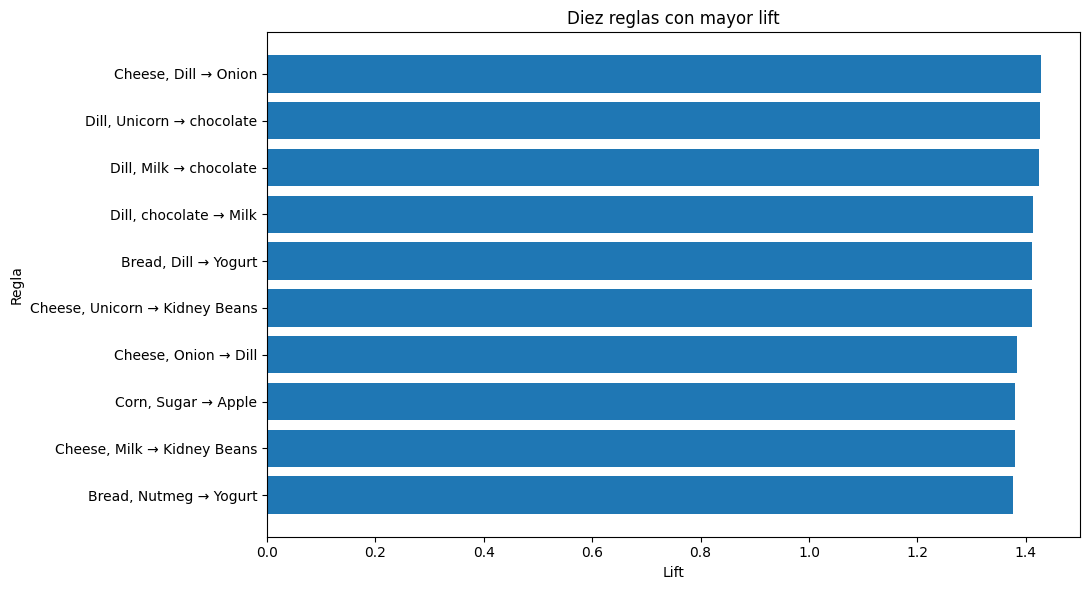

In [37]:
# Diez reglas con mayor lift
if not reglas.empty:
    mejores_lift = reglas.nlargest(10, "lift").copy()
    mejores_lift["regla"] = (
        mejores_lift["antecedente"] + " → " + mejores_lift["consecuente"]
    )

    plt.figure(figsize=(11, 6))
    plt.barh(mejores_lift["regla"][::-1], mejores_lift["lift"][::-1])
    plt.title("Diez reglas con mayor lift")
    plt.xlabel("Lift")
    plt.ylabel("Regla")
    plt.tight_layout()
    plt.show()


In [38]:
# Interpretación automática de las cinco reglas principales
if not reglas.empty:
    for posicion, (_, fila) in enumerate(reglas.head(5).iterrows(), start=1):
        tipo_asociacion = (
            "positiva" if fila["lift"] > 1
            else "independiente" if np.isclose(fila["lift"], 1)
            else "negativa"
        )

        print(
            f"Regla {posicion}: si se compra [{fila['antecedente']}], "
            f"también se compra [{fila['consecuente']}] con una confianza de "
            f"{fila['confianza']:.2%}. El soporte conjunto es "
            f"{fila['soporte']:.2%} y el lift es {fila['lift']:.3f}, "
            f"lo que representa una asociación {tipo_asociacion}."
        )


Regla 1: si se compra [Cheese, Dill], también se compra [Onion] con una confianza de 57.63%. El soporte conjunto es 10.21% y el lift es 1.429, lo que representa una asociación positiva.
Regla 2: si se compra [Dill, Unicorn], también se compra [chocolate] con una confianza de 60.12%. El soporte conjunto es 10.11% y el lift es 1.427, lo que representa una asociación positiva.
Regla 3: si se compra [Dill, Milk], también se compra [chocolate] con una confianza de 60.00%. El soporte conjunto es 11.41% y el lift es 1.424, lo que representa una asociación positiva.
Regla 4: si se compra [Dill, chocolate], también se compra [Milk] con una confianza de 57.29%. El soporte conjunto es 11.41% y el lift es 1.413, lo que representa una asociación positiva.
Regla 5: si se compra [Bread, Dill], también se compra [Yogurt] con una confianza de 59.38%. El soporte conjunto es 9.51% y el lift es 1.412, lo que representa una asociación positiva.


### Análisis de sensibilidad

Para justificar mejor el soporte mínimo, se compara cuántos conjuntos frecuentes y reglas se obtienen con diferentes valores. Un soporte menor produce más resultados, pero también puede incluir asociaciones poco representativas.


In [39]:
# Comparación de diferentes umbrales de soporte
resultados_sensibilidad = []

for soporte_prueba in [0.05, 0.08, 0.10, 0.15]:
    soportes_prueba, itemsets_prueba = apriori_booleano(
        datos,
        soporte_minimo=soporte_prueba,
        max_tamano=max_tamano
    )
    reglas_prueba = generar_reglas(
        soportes_prueba,
        confianza_minima=confianza_minima,
        lift_minimo=lift_minimo
    )

    resultados_sensibilidad.append({
        "Soporte mínimo": soporte_prueba,
        "Itemsets frecuentes": len(itemsets_prueba),
        "Reglas": len(reglas_prueba)
    })

sensibilidad = pd.DataFrame(resultados_sensibilidad)
display(sensibilidad)


,Soporte mínimo,Itemsets frecuentes,Reglas
0,0.0500,696,552
1,0.0800,615,548
2,0.1000,169,97
3,0.1500,136,5


## Conclusiones

1. El dataset se carga directamente desde Google Drive y se valida antes del modelado.
2. La preparación transforma los productos en una matriz transaccional booleana sin eliminar silenciosamente valores inválidos.
3. Apriori identifica productos y combinaciones que alcanzan el soporte mínimo establecido.
4. Las reglas se evalúan mediante soporte, confianza, lift, leverage y conviction.
5. Un lift mayor que 1 señala una asociación positiva, pero no demuestra una relación causal.
6. El análisis de sensibilidad permite observar cómo cambia la cantidad de resultados al modificar el soporte mínimo.
7. Los archivos finales se almacenan en Google Drive para facilitar su reutilización y presentación.
